In [53]:
!nvidia-smi

Sun Sep  1 22:35:56 2024       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 560.35.03              Driver Version: 560.35.03      CUDA Version: 12.6     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX A2000 12GB          Off |   00000000:61:00.0 Off |                  Off |
| 30%   51C    P8              6W /   70W |       4MiB /  12282MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [5]:
!pip install tensorrt

In [6]:
!pip install ultralytics


In [7]:
!pip install opencv-python torch matplotlib


In [8]:
!pip install opencv-python torch matplotlib


In [9]:
import ultralytics
print(ultralytics.__version__)


8.0.196


In [10]:
!pip install torch torchvision torchaudio


In [11]:
!pip install pandas


In [12]:
!pip install seaborn matplotlib


In [13]:
!pip install tensorboard


In [14]:
!pip install albumentations


In [15]:
!pip install tqdm


In [16]:
!pip install pyyaml


In [17]:
!pip install imageio


In [18]:
!pip install shapely


In [19]:
!pip install pycocotools


In [20]:
!pip install opencv-contrib-python


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.7/68.7 MB 26.3 MB/s eta 0:00:0000:0100:01


In [21]:
!pip install nvidia-tensorrt


In [22]:
import tensorflow as tf

# Set TensorFlow to use CPU
tf.config.set_visible_devices([], 'GPU')


2024-09-01 22:16:23.600832: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-09-01 22:16:23.617729: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-09-01 22:16:23.622863: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [23]:
import tensorflow as tf

# Set TensorFlow to use CPU
tf.config.set_visible_devices([], 'GPU')


In [28]:
!python detect.py --weights best.pt --img 640 --conf 0.2 --source /path/to/images --device cpu



python: can't open file '/home/mangrove/mangrove/detect.py': [Errno 2] No such file or directory


In [77]:
import os
HOME = os.getcwd()
print(HOME)

/home/mangrove/mangrove


In [76]:
# Pip install method (recommended)

!pip install ultralytics==8.0.196

from IPython import display
display.clear_output()

import ultralytics
ultralytics.checks()

Ultralytics YOLOv8.0.196 🚀 Python-3.10.12 torch-2.4.0+cu121 CUDA:0 (NVIDIA RTX A2000 12GB, 11935MiB)
Setup complete ✅ (24 CPUs, 31.0 GB RAM, 66.8/97.9 GB disk)


In [39]:
from ultralytics import YOLO

from IPython.display import display, Image

In [42]:
ls

datasets/              reCopy_of_yolov8n_mangrove.ipynb  yolov8n.pt
mangrove-detection-2/  runs/                             yolov8x.pt


In [48]:
!mkdir {HOME}/datasets


mkdir: cannot create directory ‘/home/mangrove/mangrove/datasets’: File exists


In [49]:
%cd {HOME}/datasets

/home/mangrove/mangrove/datasets


In [31]:


!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="SmutrcE1hpSEpSDb2Hbk")
project = rf.workspace("mangrove-i43zl").project("mangrove-detection")
version = project.version(2)
dataset = version.download("yolov8")




loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to mangrove-detection-2 in yolov8:: 100%|██████████| 3038/3038 [00:00<00:00, 7837.39it/s]


## Custom Training

In [50]:
import torch
torch.cuda.empty_cache()

In [55]:
%cd {HOME}

!yolo task=detect mode=train model=yolov8x.pt data={dataset.location}/data.yaml epochs=200 imgsz=412 plots=True patience=0


/home/mangrove/mangrove
/home/mangrove/jupyter_env/myenv/lib/python3.10/site-packages/ultralytics/nn/tasks.py:567: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch

In [63]:
!ls {HOME}/runs/detect/train/

args.yaml					  labels.jpg
events.out.tfevents.1725203195.cbr2server.3002.0  weights
labels_correlogram.jpg


/home/mangrove/mangrove


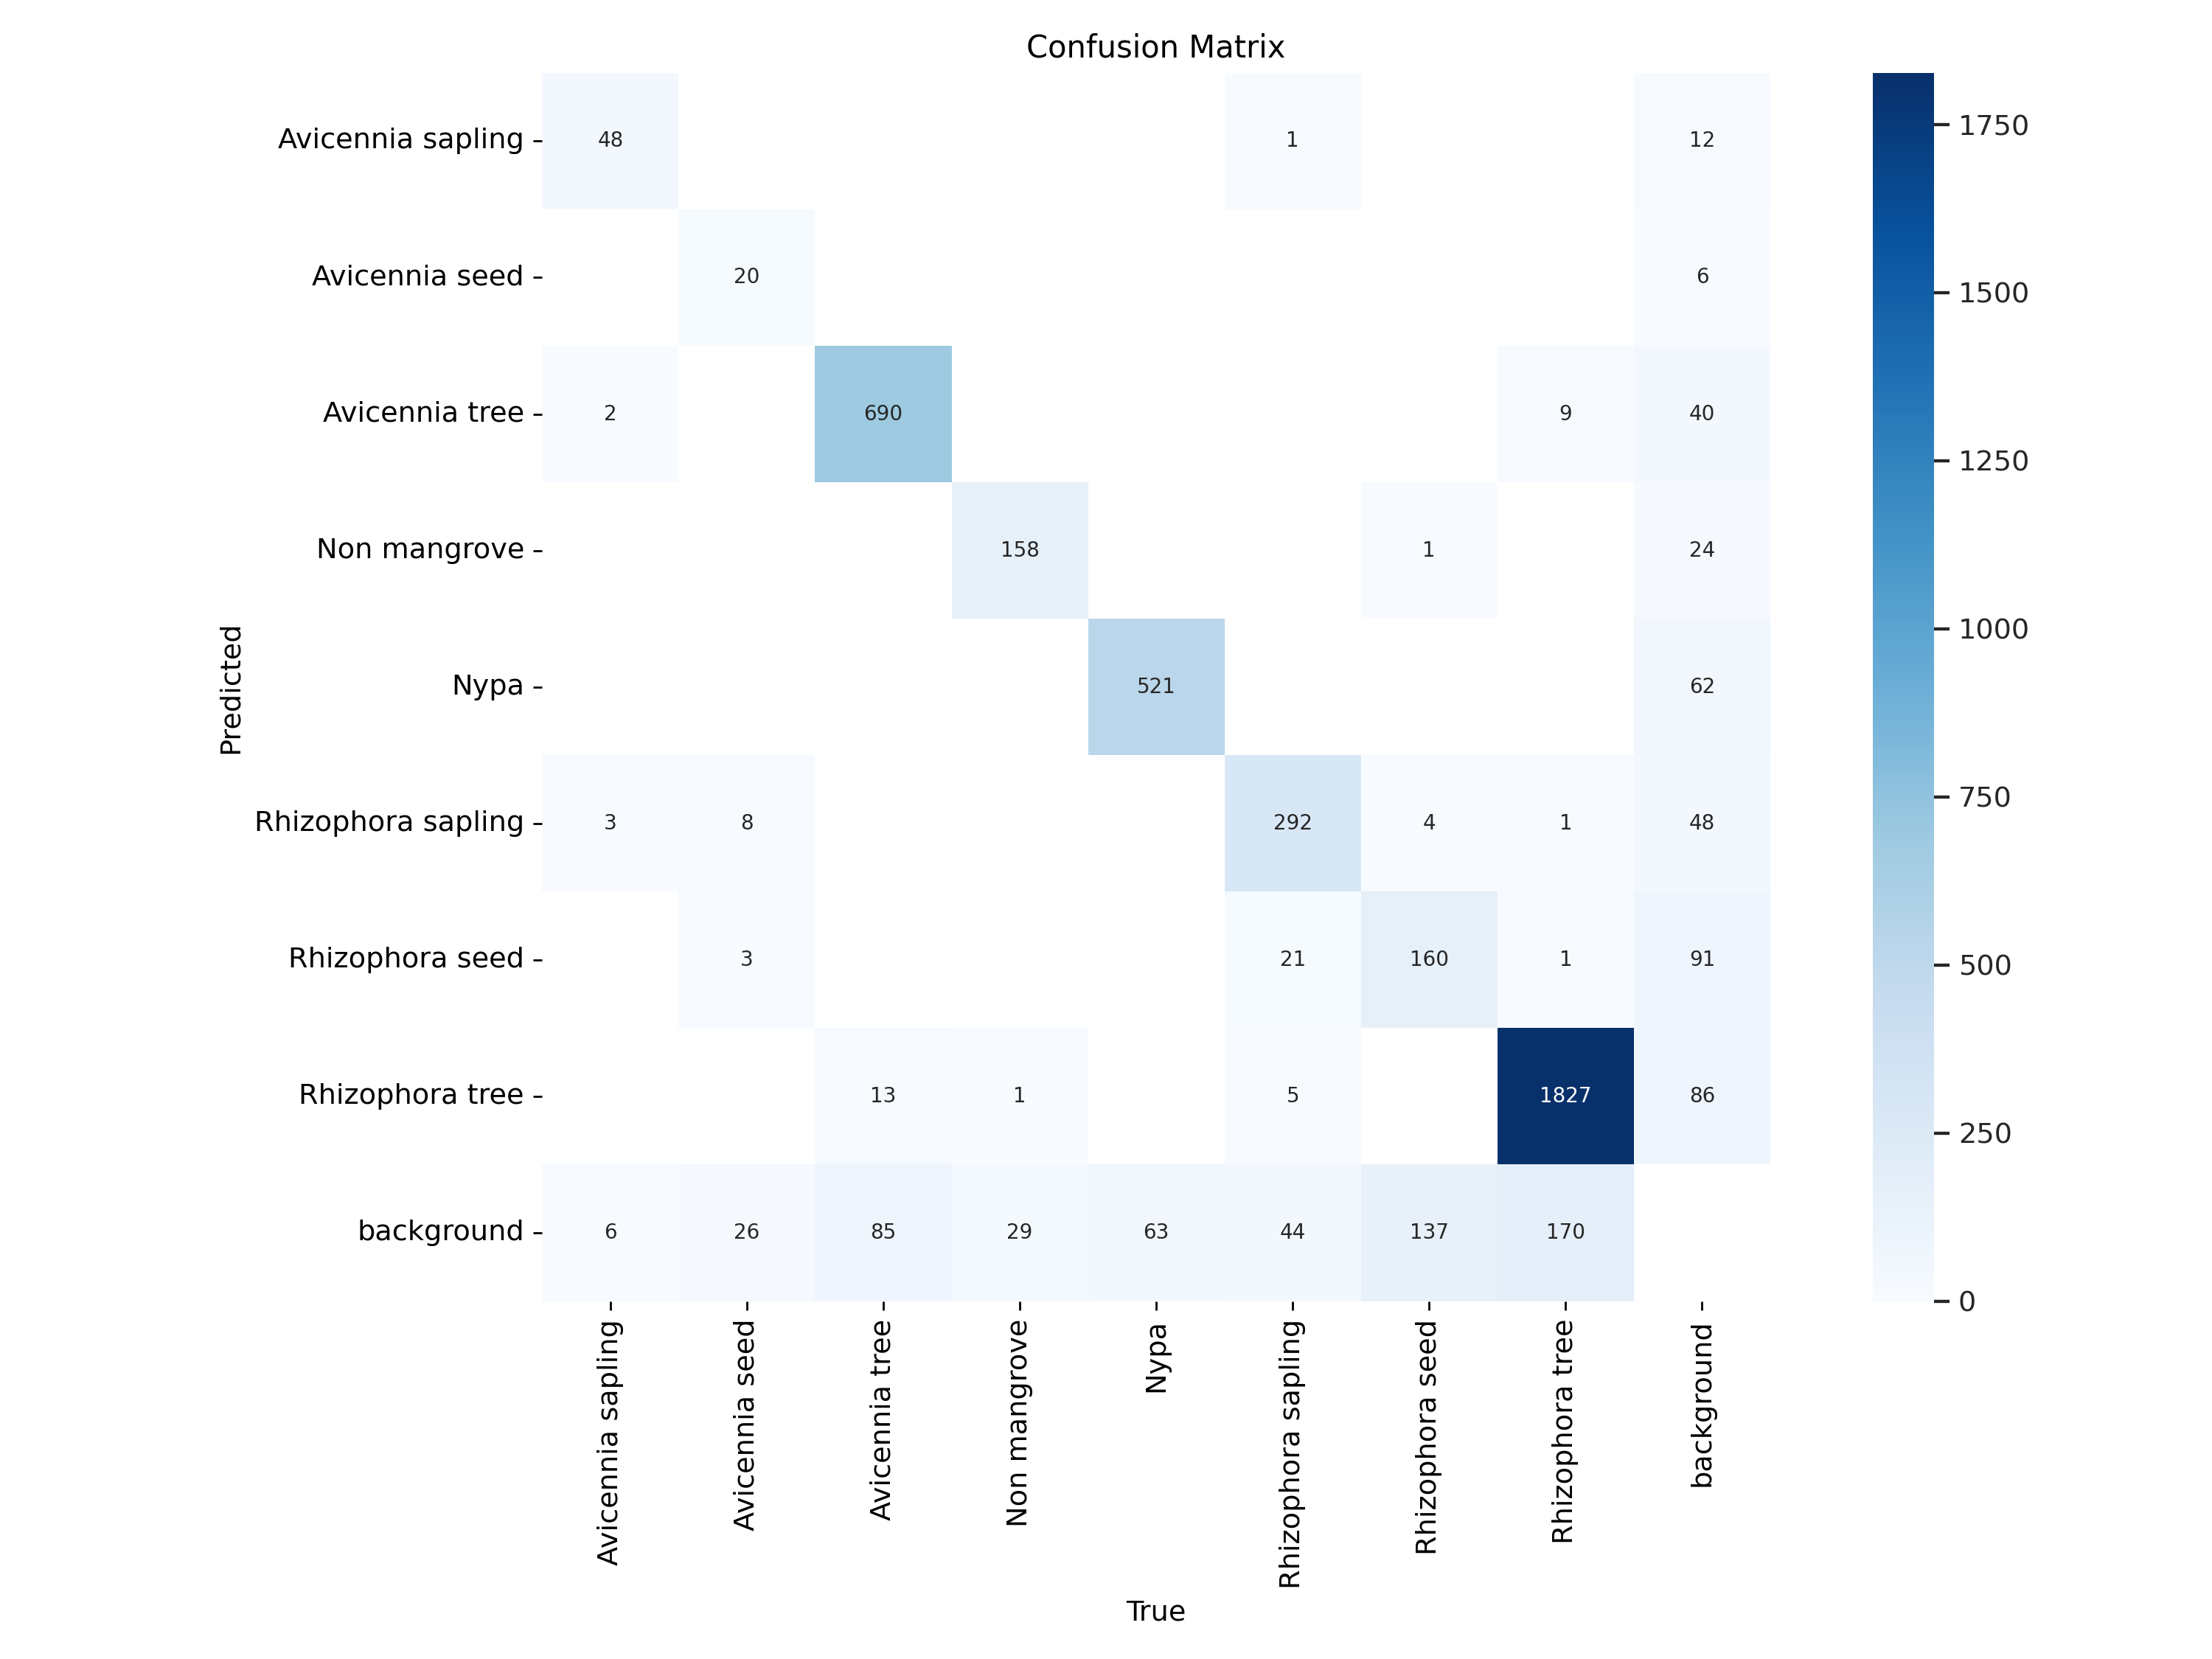

In [83]:
%cd {HOME}
Image(filename=f'{HOME}/runs/detect/train10/confusion_matrix.png', width=600)

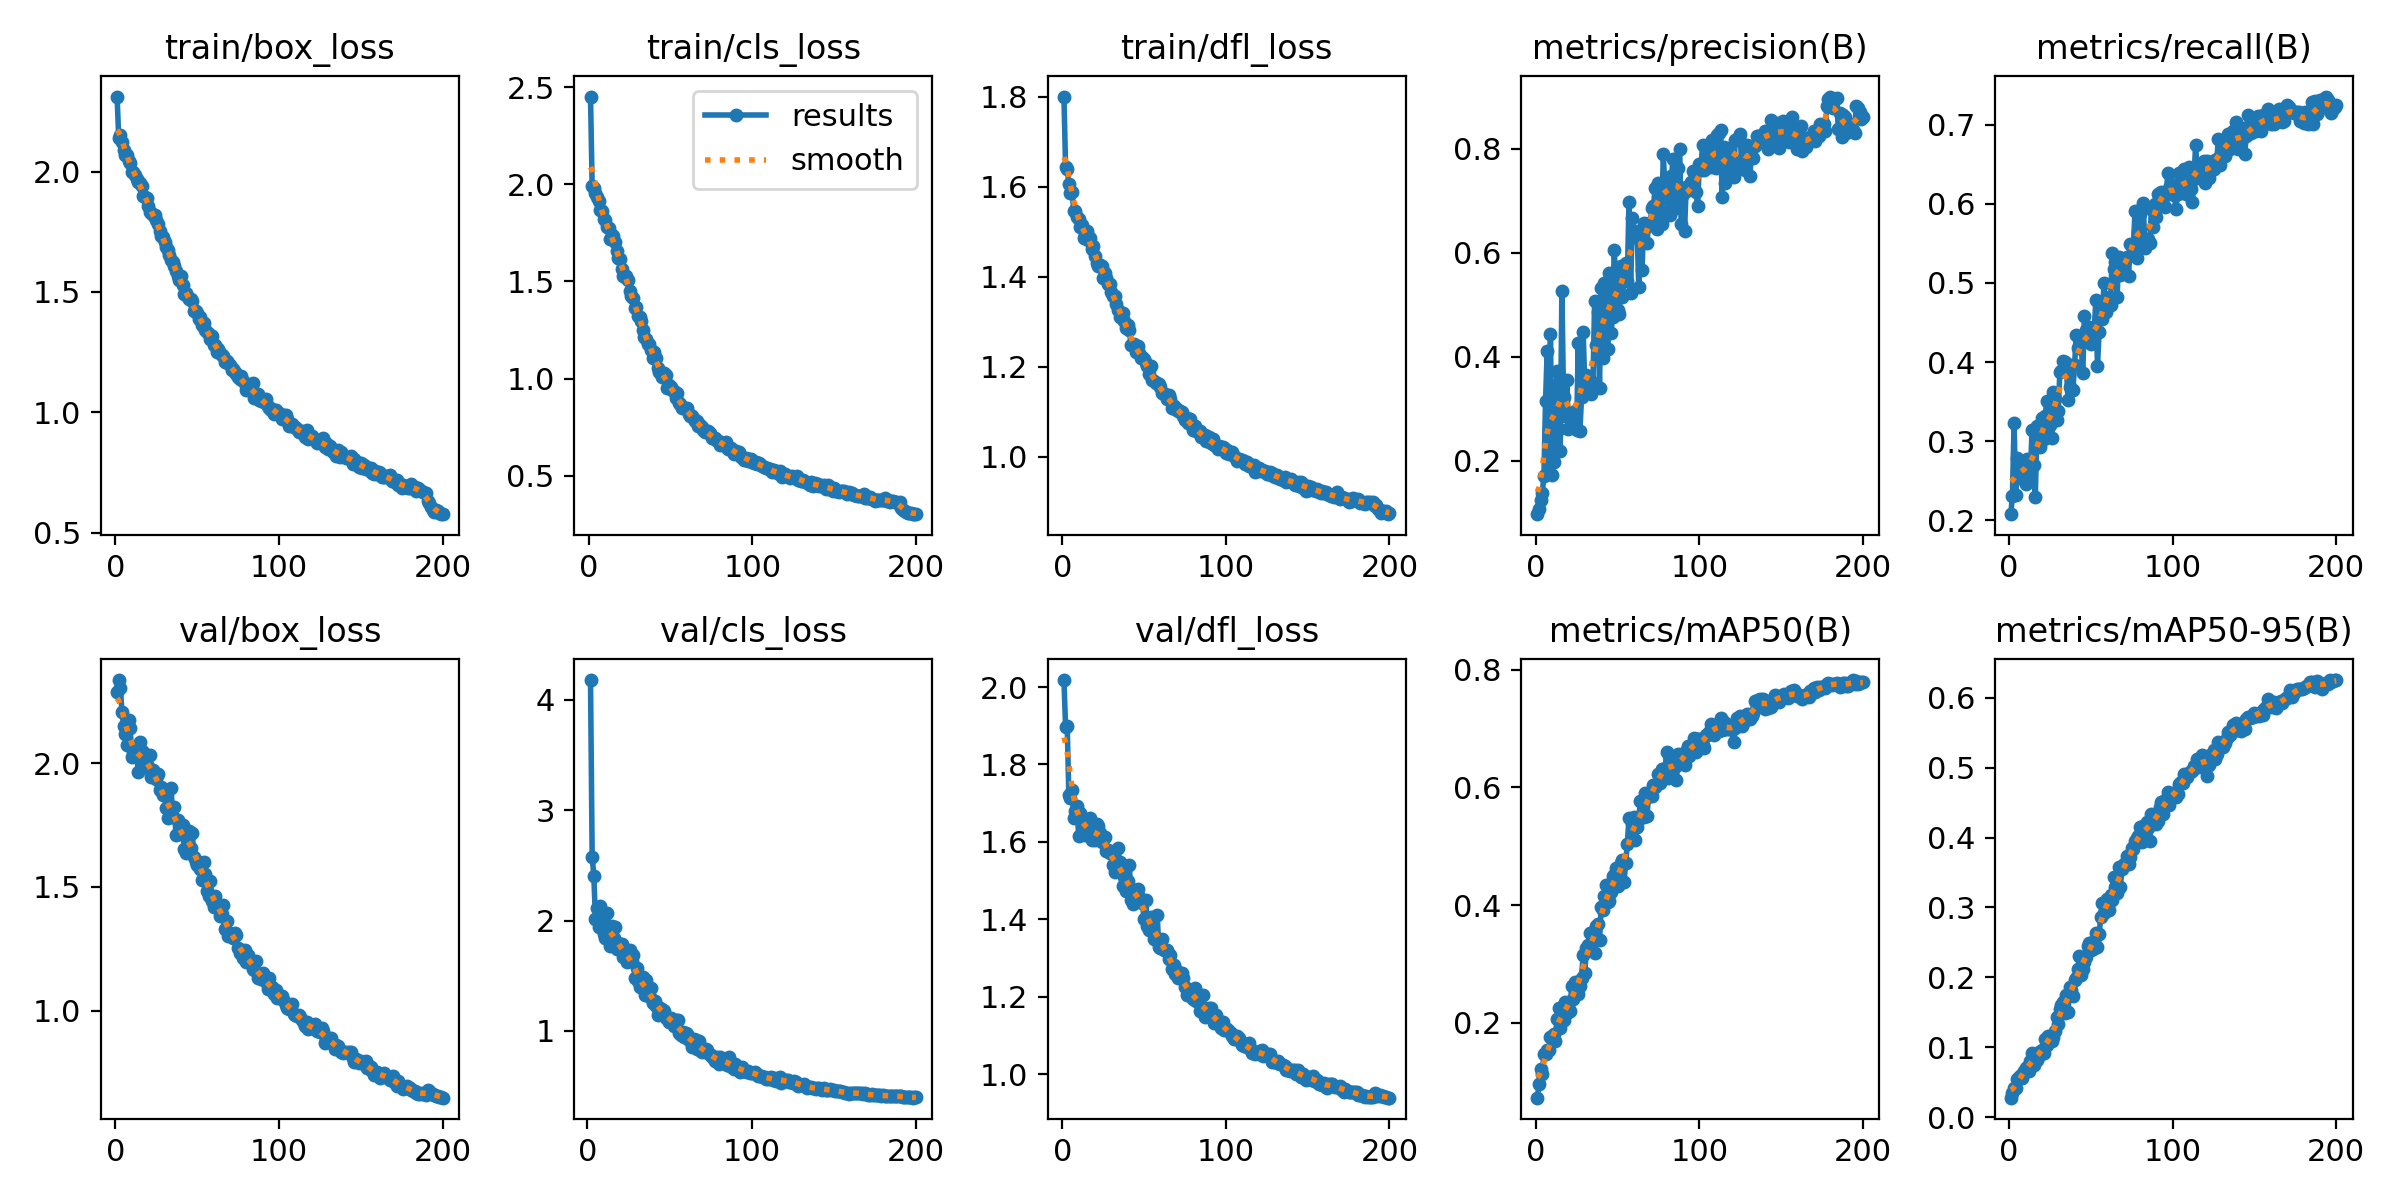

In [86]:
#%cd {HOME}
Image(filename=f'{HOME}/runs/detect/train10/results.png', width=600)

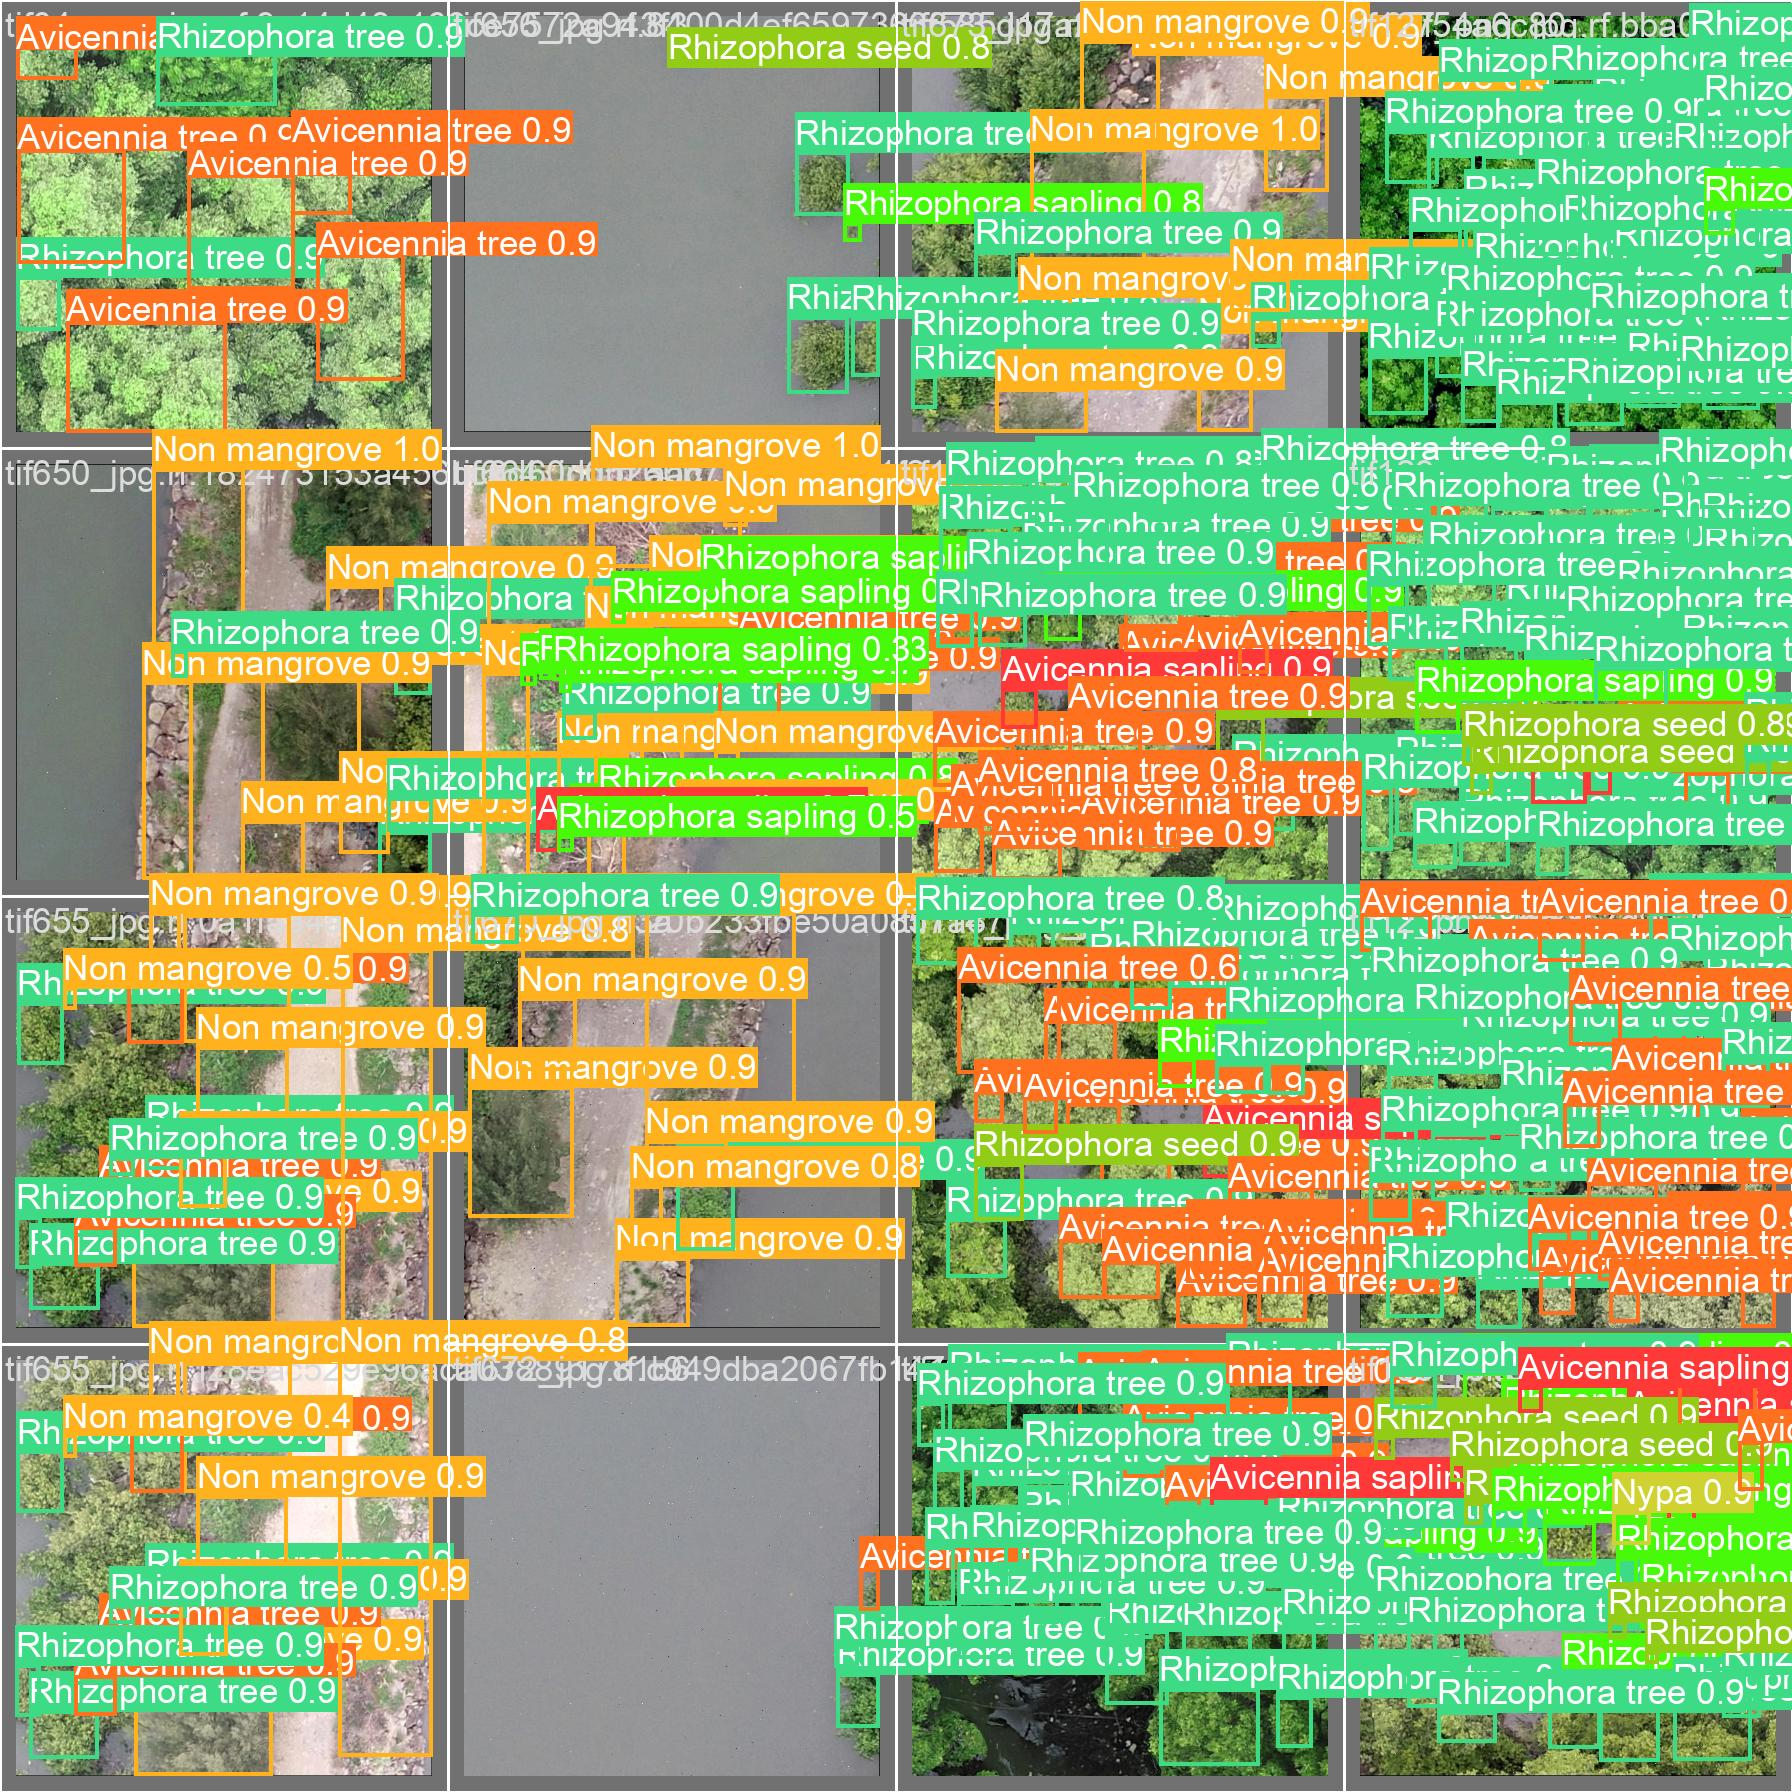

In [118]:
#%cd {HOME}
Image(filename=f'{HOME}/runs/detect/train10/val_batch0_pred.jpg', width=600)

## Validate Custom Model

In [114]:
%cd {HOME}

!yolo task=detect mode=val model={HOME}/runs/detect/train10/weights/best.pt data={dataset.location}/data.yaml

/home/mangrove/mangrove
/home/mangrove/jupyter_env/myenv/lib/python3.10/site-packages/ultralytics/nn/tasks.py:567: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch

## Inference with Custom Model

In [119]:
%cd {HOME}
!yolo task=detect mode=predict model={HOME}/runs/detect/train10/weights/best.pt conf=0.25 source={dataset.location}/test/images save=True

/home/mangrove/mangrove
/home/mangrove/jupyter_env/myenv/lib/python3.10/site-packages/ultralytics/nn/tasks.py:567: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch

**NOTE:** Let's take a look at few results.

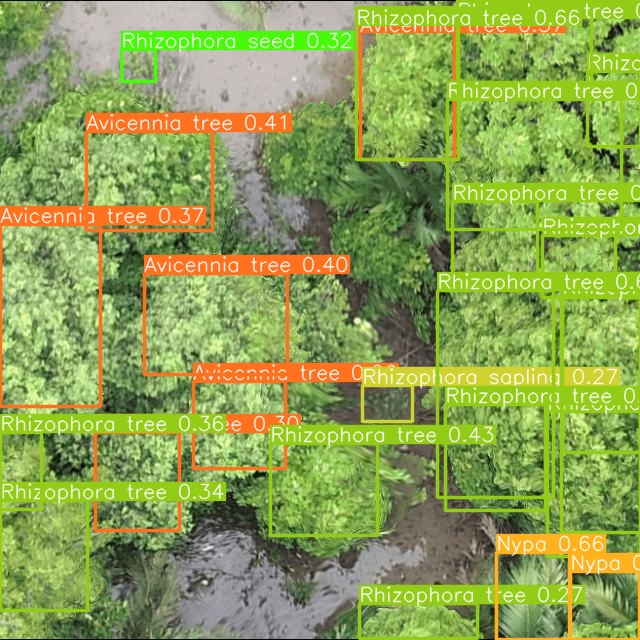

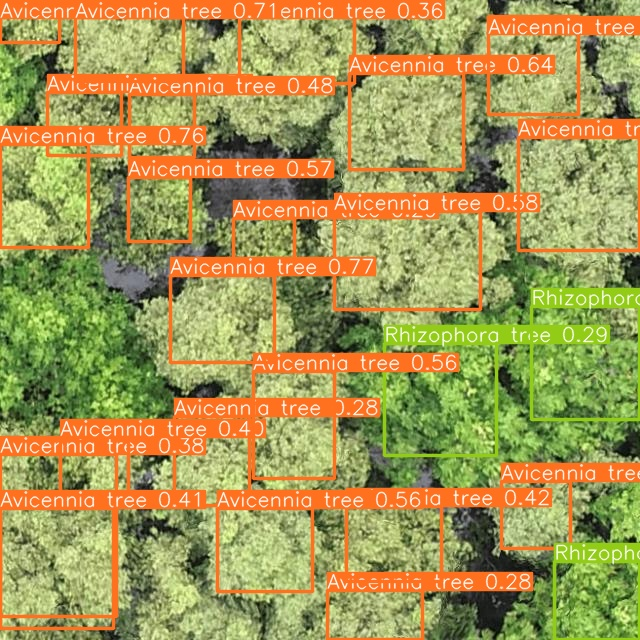

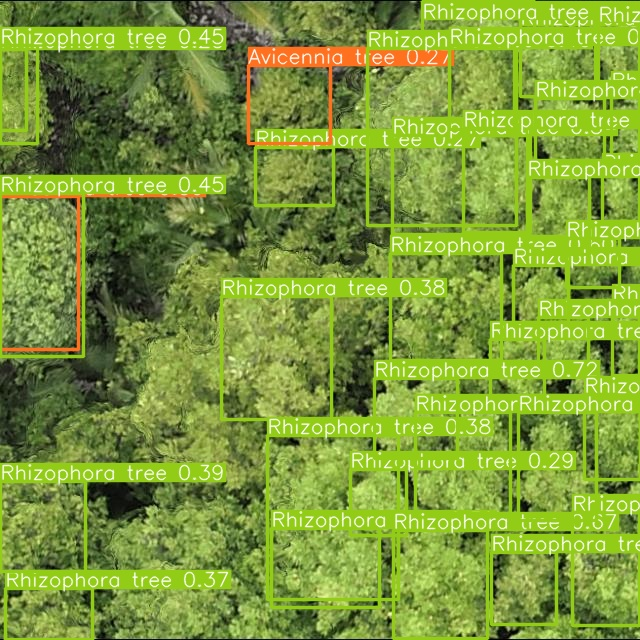

In [ ]:
import glob
from IPython.display import Image, display

# Define the base path where the folders are located
base_path = '/content/runs/detect/'

# List all directories that start with 'predict' in the base path
subfolders = [os.path.join(base_path, d) for d in os.listdir(base_path)
              if os.path.isdir(os.path.join(base_path, d)) and d.startswith('predict')]

# Find the latest folder by modification time
latest_folder = max(subfolders, key=os.path.getmtime)

image_paths = glob.glob(f'{latest_folder}/*.jpg')[:3]

# Display each image
for image_path in image_paths:
    display(Image(filename=image_path, width=600))
    print("\n")

## Deploy model on Roboflow

Once you have finished training your YOLOv8 model, you’ll have a set of trained weights ready for use. These weights will be in the `/runs/detect/train/weights/best.pt` folder of your project. You can upload your model weights to Roboflow Deploy to use your trained weights on our infinitely scalable infrastructure.

The `.deploy()` function in the [Roboflow pip package](https://docs.roboflow.com/python) now supports uploading YOLOv8 weights.

To upload model weights, add the following code to the “Inference with Custom Model” section in the aforementioned notebook:

In [ ]:
project.version(dataset.version).deploy(model_type="yolov8", model_path=f"{HOME}/runs/detect/train/")

View the status of your deployment at: https://app.roboflow.com/roboflow-jvuqo/football-players-detection-3zvbc/1
Share your model with the world at: https://universe.roboflow.com/roboflow-jvuqo/football-players-detection-3zvbc/1


In [ ]:
#While your deployment is processing, checkout the deployment docs to take your model to most destinations https://docs.roboflow.com/inference

In [ ]:
#Run inference on your model on a persistant, auto-scaling, cloud API

#load model
model = project.version(dataset.version).model

#choose random test set image
import os, random
test_set_loc = dataset.location + "/test/images/"
random_test_image = random.choice(os.listdir(test_set_loc))
print("running inference on " + random_test_image)

pred = model.predict(test_set_loc + random_test_image, confidence=40, overlap=30).json()
pred

# Deploy Your Model to the Edge

In addition to using the Roboflow hosted API for deployment, you can use [Roboflow Inference](https://inference.roboflow.com), an open source inference solution that has powered millions of API calls in production environments. Inference works with CPU and GPU, giving you immediate access to a range of devices, from the NVIDIA Jetson to TRT-compatible devices to ARM CPU devices.

With Roboflow Inference, you can self-host and deploy your model on-device. You can deploy applications using the [Inference Docker containers](https://inference.roboflow.com/quickstart/docker/) or the pip package.

For example, to install Inference on a device with an NVIDIA GPU, we can use:

```
docker pull roboflow/roboflow-inference-server-gpu
```

Then we can run inference via HTTP:

```python
import requests

workspace_id = ""
model_id = ""
image_url = ""
confidence = 0.75
api_key = ""

infer_payload = {
    "image": {
        "type": "url",
        "value": image_url,
    },
    "confidence": confidence,
    "iou_threshold": iou_thresh,
    "api_key": api_key,
}
res = requests.post(
    f"http://localhost:9001/{workspace_id}/{model_id}",
    json=infer_object_detection_payload,
)

predictions = res.json()
```

Above, set your Roboflow workspace ID, model ID, and API key.

- [Find your workspace and model ID](https://docs.roboflow.com/api-reference/workspace-and-project-ids?ref=blog.roboflow.com)
- [Find your API key](https://docs.roboflow.com/api-reference/authentication?ref=blog.roboflow.com#retrieve-an-api-key)

Also, set the URL of an image on which you want to run inference. This can be a local file.

_To use your YOLOv5 model commercially with Inference, you will need a Roboflow Enterprise license, through which you gain a pass-through license for using YOLOv5. An enterprise license also grants you access to features like advanced device management, multi-model containers, auto-batch inference, and more._

## 🏆 Congratulations

### Learning Resources

Roboflow has produced many resources that you may find interesting as you advance your knowledge of computer vision:

- [Roboflow Notebooks](https://github.com/roboflow/notebooks): A repository of over 20 notebooks that walk through how to train custom models with a range of model types, from YOLOv7 to SegFormer.
- [Roboflow YouTube](https://www.youtube.com/c/Roboflow): Our library of videos featuring deep dives into the latest in computer vision, detailed tutorials that accompany our notebooks, and more.
- [Roboflow Discuss](https://discuss.roboflow.com/): Have a question about how to do something on Roboflow? Ask your question on our discussion forum.
- [Roboflow Models](https://roboflow.com): Learn about state-of-the-art models and their performance. Find links and tutorials to guide your learning.

### Convert data formats

Roboflow provides free utilities to convert data between dozens of popular computer vision formats. Check out [Roboflow Formats](https://roboflow.com/formats) to find tutorials on how to convert data between formats in a few clicks.

### Connect computer vision to your project logic

[Roboflow Templates](https://roboflow.com/templates) is a public gallery of code snippets that you can use to connect computer vision to your project logic. Code snippets range from sending emails after inference to measuring object distance between detections.